<a href="https://colab.research.google.com/github/emanuelmejia/course_time_series_python/blob/main/X-Challenge/Challenge_Final_2026.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Importación Módulos y Funciones**

In [1]:
# Data management
import numpy as np
import pandas as pd

# DataViz
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import seaborn as sns
import altair as alt
from sklearn.metrics import mean_absolute_error, mean_squared_error

In [2]:
def metricasPrecision(real, pronostico):
      resultados = {}

      # RMSE - Root Mean Squared Error
      resultados['RMSE'] = np.sqrt(mean_squared_error(real, pronostico))

      # ME - Mean Error
      resultados['ME'] = np.mean(pronostico - real)

      # MAE - Mean Absolute Error
      resultados['MAE'] = mean_absolute_error(real, pronostico)

      # MSE - Mean Squared Error
      resultados['MSE'] = mean_squared_error(real, pronostico)

      # Preparar para MPE y MAPE: manejar la división por cero
      # Reemplazar 0s con NaN para evitar la división por cero, luego filtrar NaNs
      realSinCero = real.replace(0, np.nan)
      realSinCero = realSinCero[realSinCero.notna()]
      pronosticoSinCero = pronostico[realSinCero.notna()]

      # MPE - Mean Percentage Error
      if len(realSinCero) > 0:
          resultados['MPE'] = np.mean(((realSinCero - pronosticoSinCero) / realSinCero)) * 100
      else:
          resultados['MPE'] = np.nan

      # MAPE - Mean Absolute Percentage Error
      if len(realSinCero) > 0:
          resultados['MAPE'] = np.mean(np.abs((realSinCero - pronosticoSinCero) / realSinCero)) * 100
      else:
          resultados['MAPE'] = np.nan

      return resultados

# **Importación de Datos**

In [4]:
# Subir archivo productos
from google.colab import files
files.upload()

Saving productos.csv to productos (6).csv


{'productos (6).csv': b'date,category,subcategory,key,description,qty,unitPrice,subtotal,total\n2023-09-01,BEBIDAS CALIENTES,COFFEE,1001,AMERICANO CHIBI,26,34.48,896.56,1040.0\n2023-09-01,BEBIDAS FRIAS,COFFEE,2003,COLD AMERICANO CUPHEAD,10,50.0,500.0,580.0\n2023-09-01,BEBIDAS FRIAS,COFFEE,2001,COLD AMERICANO CHIBI,10,24.14,241.38,280.0\n2023-09-01,BEBIDAS FRIAS,COFFEE,2004,LATTE FRIO,6,43.1,258.62,300.0\n2023-09-01,BEBIDAS CALIENTES,COFFEE,1003,AMERICANO CUPHEAD,4,43.1,172.42,200.0\n2023-09-01,BEBIDAS FRIAS,FRAPPES,2005,MALTEADA,2,64.66,129.32,150.0\n2023-09-01,BEBIDAS FRIAS,COFFEE,2002,COLD AMERICANO CLUB,2,30.17,60.34,70.0\n2023-09-01,BEBIDAS CALIENTES,COFFEE,1009,CAFE CON LECHE,2,34.48,68.96,80.0\n2023-10-01,MODIFICADORES,LECHE,99001,L1-LECHE LIGHT,122,1.72,210.34,208.8\n2023-10-01,ALIMENTOS,ENTSALADITAS,3002,ENTSALADITA TSIBI,68,50.86,3458.62,3268.34\n2023-10-01,ALIMENTOS,DESSERTS,3501,REBANADA DE PANQUE,46,17.24,793.1,755.4\n2023-10-01,ALIMENTOS,MOLLETSIBI,3004,MOLLEPIZZA PEPPERON

In [5]:
dfProd = pd.read_csv("/content/productos.csv", encoding='latin1')
dfProd['date'] = pd.to_datetime(dfProd['date'])
dfProd = dfProd.set_index('date')
dfProd.head()

,category,subcategory,key,description,qty,unitPrice,subtotal,total
date,,,,,,,,
2023-09-01,BEBIDAS CALIENTES,COFFEE,1001,AMERICANO CHIBI,26,34.48,896.56,1040.0
2023-09-01,BEBIDAS FRIAS,COFFEE,2003,COLD AMERICANO CUPHEAD,10,50.00,500.00,580.0
2023-09-01,BEBIDAS FRIAS,COFFEE,2001,COLD AMERICANO CHIBI,10,24.14,241.38,280.0
2023-09-01,BEBIDAS FRIAS,COFFEE,2004,LATTE FRIO,6,43.10,258.62,300.0
2023-09-01,BEBIDAS CALIENTES,COFFEE,1003,AMERICANO CUPHEAD,4,43.10,172.42,200.0


In [6]:
# Agrupar ventas mensuales por Dataset
dfCat = dfProd.groupby(['date', 'category'])['total'].sum().reset_index()

# rellenar categorías-meses con ventas 0
all_dates = pd.date_range(start=dfCat['date'].min(), end=dfCat['date'].max(), freq='MS')
all_categories = dfCat['category'].unique()
full_index = pd.MultiIndex.from_product([all_dates, all_categories], names=['date', 'category'])
full_df = pd.DataFrame(index=full_index).reset_index()
dfCat = pd.merge(full_df, dfCat, on=['date', 'category'], how='left')
dfCat['total'] = dfCat['total'].fillna(0)

dfCat = dfCat.set_index('date')

dfCat.head(10)

,category,total
date,,
2023-09-01,BEBIDAS CALIENTES,1320.00
2023-09-01,BEBIDAS FRIAS,1380.00
2023-09-01,ALIMENTOS,0.00
2023-09-01,MODIFICADORES,0.00
2023-09-01,PAQUETES,0.00
2023-09-01,PROMOCIONALES,0.00
2023-10-01,BEBIDAS CALIENTES,14684.28
2023-10-01,BEBIDAS FRIAS,10973.00
2023-10-01,ALIMENTOS,13039.60


In [7]:
# Agrupar ventas mensuales totales
df = dfCat.groupby('date')['total'].sum().reset_index()
df = df.set_index('date')

# Crear la nueva columna 'Dataset' con valores 'Train' para 2025 y antes, y 'Validation' para 2026
df['Dataset'] = np.where(df.index.year <= 2025, 'Train', 'Validation')

df.head()

,total,Dataset
date,,
2023-09-01,2700.00,Train
2023-10-01,39016.04,Train
2023-11-01,43017.20,Train
2023-12-01,33834.82,Train
2024-01-01,37582.90,Train


# **Ejercicio final**

Ajusta un modelo a las ventas totales por mes y elabora un pronóstico para los siguientes 6 meses (Ene26-Jun26)

In [8]:
# Font para etiquetas y títulos
fontEti = {'family':'serif','color':'cornflowerblue','size': 18, 'fontweight': 'bold'}
fontTit = {'family':'serif','color':'cornflowerblue','size': 25, 'fontweight': 'bold'}

# Formato de moneda para ticks
fmoneda = '${x:,.0f}'
tick = mtick.StrMethodFormatter(fmoneda)

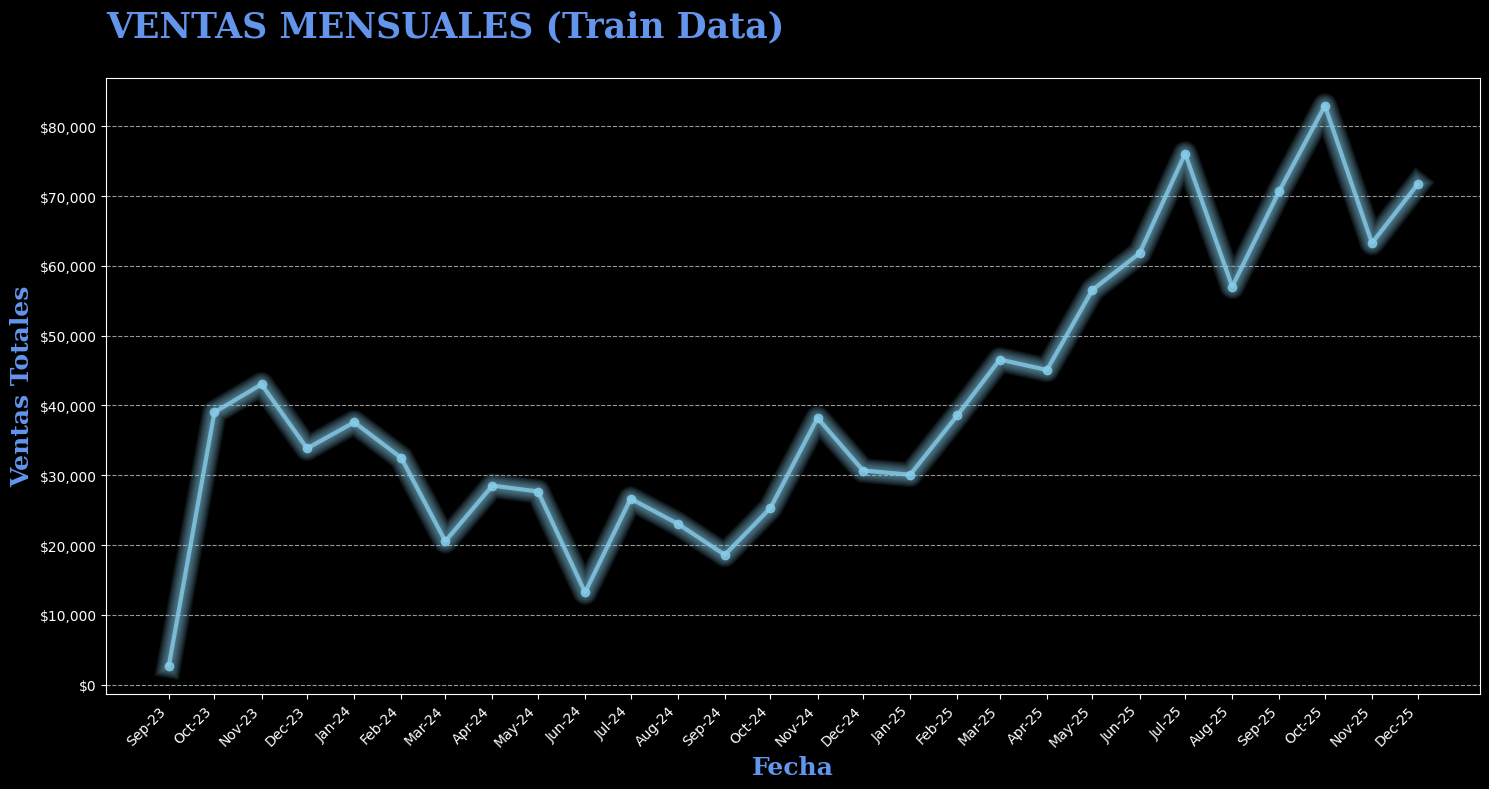

In [9]:
#  Aplicar background
plt.style.use('dark_background')
fig, ax = plt.subplots(figsize=(15, 8))

# Filtrar el DataFrame para incluir solo los datos de 'Train'
dfTrain = df[df['Dataset'] == 'Train']

# Parámetros para línea brillante
base_color = 'skyblue'
n_glows = 10
base_linewidth = 3
base_opacity = 0.8

# Graficar varias veces para dar efecto de brillo
for i in range(1, n_glows + 1):
    ax.plot(dfTrain.index,
            dfTrain['total'],
            color=base_color,
            linewidth=base_linewidth + (i * 1.5),
            alpha=base_opacity / n_glows)

# Graficar la línea principal encima
ax.plot(dfTrain.index,
        dfTrain['total'],
        marker='o',
        linewidth= base_linewidth,
        color=base_color,
        alpha=base_opacity)


# Etiquetas
ax.set_title('VENTAS MENSUALES (Train Data)', fontdict=fontTit, loc='left', pad=30)
ax.set_xlabel('Fecha', fontdict=fontEti)
ax.set_ylabel('Ventas Totales', fontdict=fontEti)
ax.set_xticks(dfTrain.index) # Pedir explícitamente las etiquetas de x
ax.set_xticklabels(dfTrain.index.strftime('%b-%y'), rotation=45, ha='right')
ax.yaxis.set_major_formatter(tick) # Aplicar formato de moneda en x

# Formato al enrejado del gráfico
ax.grid(False, axis = 'x')
ax.grid(axis='y', linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

# **Modelos Elegidos**

In [10]:
mod1 = {
    'date': pd.to_datetime(['2026-01-01', '2026-02-01', '2026-03-01', '2026-04-01', '2026-05-01', '2026-06-01']),
    'total': [67597.024089, 74406.761434, 72737.950247, 82346.529985, 84452.218093, 72679.431771]
}
df_mod1 = pd.DataFrame(mod1)
df_mod1 = df_mod1.set_index('date')
df_mod1['Dataset'] = 'Modelo_1'

df = pd.concat([df, df_mod1])

In [11]:
mod2 = {
    'date': pd.to_datetime(['2026-01-01', '2026-02-01', '2026-03-01', '2026-04-01', '2026-05-01', '2026-06-01']),
    'total': [74409.72, 75304.56, 70600.33, 78520.88, 91266.43, 88046.06]
}
df_mod2 = pd.DataFrame(mod2)
df_mod2 = df_mod2.set_index('date')
df_mod2['Dataset'] = 'Modelo_2'

df = pd.concat([df, df_mod2])

In [12]:
mod3 = {
    'date': pd.to_datetime(['2026-01-01', '2026-02-01', '2026-03-01', '2026-04-01', '2026-05-01', '2026-06-01']),
    'total': [104187.780440, 49319.783149, 82618.320614, 87910.416447, 83375.449894, 67359.830647]
}
df_mod3 = pd.DataFrame(mod3)
df_mod3 = df_mod3.set_index('date')
df_mod3['Dataset'] = 'Modelo_3'

df = pd.concat([df, df_mod3])

In [13]:
mod4 = {
    'date': pd.to_datetime(['2026-01-01', '2026-02-01', '2026-03-01', '2026-04-01', '2026-05-01', '2026-06-01']),
    'total': [74633.13, 75528.31, 68052.66, 75886.74, 85414.27, 75391.91]
}
df_mod4 = pd.DataFrame(mod4)
df_mod4 = df_mod4.set_index('date')
df_mod4['Dataset'] = 'Modelo_4'

df = pd.concat([df, df_mod4])

In [14]:
mod5 = {
    'date': pd.to_datetime(['2026-01-01', '2026-02-01', '2026-03-01', '2026-04-01', '2026-05-01', '2026-06-01']),
    'total': [83468.488385, 63554.215688, 71834.088056, 83557.496535, 63603.457696, 71861.330228]
}
df_mod5 = pd.DataFrame(mod5)
df_mod5 = df_mod5.set_index('date')
df_mod5['Dataset'] = 'Modelo_5'

df = pd.concat([df, df_mod5])

In [15]:
mod6 = {
    'date': pd.to_datetime(['2026-01-01', '2026-02-01', '2026-03-01', '2026-04-01', '2026-05-01', '2026-06-01']),
    'total': [70088.61, 70387.18, 70330.92, 70341.52, 70339.53, 70339.90]
}
df_mod6 = pd.DataFrame(mod6)
df_mod6 = df_mod6.set_index('date')
df_mod6['Dataset'] = 'Modelo_6'

df = pd.concat([df, df_mod6])

In [16]:
mod7 = {
    'date': pd.to_datetime(['2026-01-01', '2026-02-01', '2026-03-01', '2026-04-01', '2026-05-01', '2026-06-01']),
    'total': [74423.633654, 72682.695652, 82186.575201, 89629.644250, 95656.856015, 94965.574312]
}
df_mod7 = pd.DataFrame(mod7)
df_mod7 = df_mod7.set_index('date')
df_mod7['Dataset'] = 'Modelo_7'

df = pd.concat([df, df_mod7])

# **Pronósticos**

MODELOS ELEGIDOS:

- *Modelo 1:* Holt Winters - $T=Add$ ; $S_{12}=Add$ ; $\alpha = 0.4852$ ; $\beta = 0$ ; $\gamma = 0$
- *Modelo 2:* Holt Winters - $T=Mul$ ; $S_{12}=Mul$ ; $\alpha = 0.5021$ ; $\beta = 0$ ; $\gamma = 0$
- *Modelo 3:* ARIMAX Manual $(5,1,0)$ + $x_1$=*café_tostado* + $x_2$ = *derivados de leche*
- *Modelo 4:* Holt Winters BoxCox - $T=Add$ ; $S_{12}=Mul$ ; $\alpha = 0.4484$ ; $\beta = 0$ ; $\gamma = 0$
- *Modelo 5:* SARIMA$(1, 0, 0)(0, 1, 0)_{3}$
- *Modelo 6:* ARIMA $(0,1,0)$
- *Modelo 7:* SARIMA$(2, 1, 2)(0, 1, 1)_{12}$

In [17]:
dfForecasts = df[df['Dataset'] != 'Train']
dfForecasts = dfForecasts.pivot_table(index='date', columns='Dataset', values='total')
dfForecasts

Dataset,Modelo_1,Modelo_2,Modelo_3,Modelo_4,Modelo_5,Modelo_6,Modelo_7,Validation
date,,,,,,,,
2026-01-01,67597.024089,74409.72,104187.780440,74633.13,83468.488385,70088.61,74423.633654,64568.00
2026-02-01,74406.761434,75304.56,49319.783149,75528.31,63554.215688,70387.18,72682.695652,58741.06
2026-03-01,72737.950247,70600.33,82618.320614,68052.66,71834.088056,70330.92,82186.575201,112940.90
2026-04-01,82346.529985,78520.88,87910.416447,75886.74,83557.496535,70341.52,89629.644250,109084.40
2026-05-01,84452.218093,91266.43,83375.449894,85414.27,63603.457696,70339.53,95656.856015,149968.26
2026-06-01,72679.431771,88046.06,67359.830647,75391.91,71861.330228,70339.90,94965.574312,150293.76


# **Resultados**

In [18]:
modelos = [f'Modelo_{i}' for i in range(1, 8)]
precision = []

for nombreMod in modelos:
    metricas = metricasPrecision(dfForecasts['Validation'], dfForecasts[nombreMod])
    metricas['Modelo'] = nombreMod
    precision.append(metricas)

df_metricas = pd.DataFrame(precision)

df_metricas = df_metricas[['Modelo'] + [col for col in df_metricas.columns if col != 'Modelo']] # Reordenar columnas para poner primero el modelo
df_metricas = df_metricas.sort_values(by='RMSE', ascending=True) # Ordenar filas por RMSE

df_metricas

,Modelo,RMSE,ME,MAE,MSE,MPE,MAPE
6,Modelo_7,35652.852782,-22675.233486,30607.656588,1.271126e+09,13.182610,26.181949
1,Modelo_2,41670.818343,-27908.066667,36709.806667,1.736457e+09,17.104611,31.584576
0,Modelo_1,46371.894763,-31896.077397,38127.652571,2.150353e+09,20.679281,31.132713
3,Modelo_4,47041.935339,-31781.560000,40732.353333,2.212944e+09,19.815526,34.537796
2,Modelo_3,48885.790123,-28470.799801,41677.393281,2.389820e+09,16.753663,37.207438
5,Modelo_6,51987.313777,-37294.786667,43017.030000,2.702681e+09,25.193880,34.652637
4,Modelo_5,52173.289518,-34619.550569,42524.098593,2.722052e+09,22.017756,34.506447


# **Gráfico**

### Preparación de datos

In [19]:
df_alt = df.reset_index()

min_date = df_alt['date'].min()
df_alt['meses_transcurridos'] = (
    (df_alt['date'].dt.year - min_date.year) * 12 +
    (df_alt['date'].dt.month - min_date.month)
)

df_alt.head()

,date,total,Dataset,meses_transcurridos
0,2023-09-01,2700.00,Train,0
1,2023-10-01,39016.04,Train,1
2,2023-11-01,43017.20,Train,2
3,2023-12-01,33834.82,Train,3
4,2024-01-01,37582.90,Train,4


In [20]:
dom = list(df_alt['Dataset'].unique())
colors = ['coral', 'chartreuse', 'gray','slategray','darkslategray', 'grey', 'slategrey', 'darkslategrey', '#7570b3']

In [21]:
slider = alt.binding_range(
    min=df_alt['meses_transcurridos'].min(),
    max=df_alt['meses_transcurridos'].max(),
    step=1,
    name='Meses transcurridos'
)

cutoff = alt.param(bind=slider, value=15)

predicate = alt.datum.meses_transcurridos <= cutoff

selector = alt.param(
    name='Month_Select',
    value=df_alt['meses_transcurridos'].min(),
    bind=slider
)

input_dropdown = alt.binding_select(
    options=[None] + dom,
    labels=['All'] + dom,
    name='Dataset: '
)

selection = alt.selection_point(
    fields=['Dataset'],
    bind='legend',
    toggle='true',
    empty='all',
    name='DatasetSelection'
)

In [22]:
def archsensei():
    background = "black"
    grid = "midnightblue"
    text = "#d3d3d3"
    return {
        "config": {
            "view": {
                "continuousWidth": 400,
                "continuousHeight": 300
            },
            "background": background,
            "axis": {
                "gridColor": grid,
                "domainColor": None,
                "tickColor": None,
                "labelColor": text,
                "titleColor": text
            },
            "legend": {
                "labelColor": text,
                "titleColor": text
            },
            "line": {
                "strokeWidth": 2
            }
        }
    }

alt.themes.register("archsensei", archsensei)
alt.theme.enable("archsensei")

/tmp/ipykernel_29511/1835403615.py:29: AltairDeprecationWarning: 
Deprecated since `altair=5.5.0`. Use altair.theme instead.
Most cases require only the following change:

    # Deprecated
    alt.themes.enable('quartz')

    # Updated
    alt.theme.enable('quartz')

If your code registers a theme, make the following change:

    # Deprecated
    def custom_theme():
        return {'height': 400, 'width': 700}
    alt.themes.register('theme_name', custom_theme)
    alt.themes.enable('theme_name')

    # Updated
    @alt.theme.register('theme_name', enable=True)
    def custom_theme():
        return alt.theme.ThemeConfig(
            {'height': 400, 'width': 700}
        )

See the updated User Guide for further details:
    https://altair-viz.github.io/user_guide/api.html#theme
    https://altair-viz.github.io/user_guide/customization.html#chart-themes
  alt.themes.register("archsensei", archsensei)


ThemeRegistry.enable('archsensei')

In [23]:
slider = alt.binding_range(
    min=df_alt['meses_transcurridos'].min(),
    max=df_alt['meses_transcurridos'].max(),
    step=1,
    name='Meses transcurridos'
)

cutoff = alt.param(bind=slider, value=15)

predicate = alt.datum.meses_transcurridos <= cutoff

selector = alt.param(
    name='Month_Select',
    value=df_alt['meses_transcurridos'].min(),
    bind=slider
)

input_dropdown = alt.binding_select(
    options=[None] + df_alt['Dataset'].unique().tolist(),
    labels=['All'] + df_alt['Dataset'].unique().tolist(),
    name='Dataset: '
)

selection = alt.selection_point(
    fields=['Dataset'],
    bind='legend',
    toggle='true',
    empty='all',
    name='DatasetSelection'
)

In [24]:
base = alt.Chart(df_alt).properties(
    title={
        "text": "VENTAS MENSUALES",
        "subtitle": "Deslice para seleccionar el rango de meses y elija Modelos",
        "color": "coral",
        "font": "Sans-Serif",
        "fontSize": 25,
        "fontWeight": "bold",
        "subtitleColor": "#d3d3d3",
        "subtitleFont": "Sans-Serif",
        "subtitleFontSize": 18,
        "subtitleFontStyle": "italic"
    },
    width=1200,
    height=600
).add_params(
    selection
)

lines = base.mark_line(point=True, strokeWidth=5).encode(
    x=alt.X('date', title='Fecha', axis=alt.Axis(format='%b-%y', labelAngle=-45)),
    y=alt.Y('total', title='Ventas', axis=alt.Axis(format='$,.0f')),
    color=alt.Color('Dataset', title='Dataset', scale = alt.Scale(domain=dom, range=colors)),
    opacity = alt.condition((alt.datum.Dataset == 'Validation') | (alt.datum.Dataset == 'Train'),
              alt.value(0.9),
              alt.value(0.4)),
    strokeWidth = alt.condition(alt.datum.Dataset == 'Validation',
              alt.value(2),
              alt.value(5)),
).transform_filter(
    selection
).transform_filter(
    predicate
)

points = base.mark_point(
    filled = True,
    stroke = 'white',
    tooltip = True
).encode(
    x=alt.X('date', title='Fecha', axis=alt.Axis(format='%b-%y', labelAngle=-45)),
    y=alt.Y('total', title='Ventas', axis=alt.Axis(format='$,.0f')),
    color=alt.Color('Dataset', title='Dataset', scale = alt.Scale(domain=dom, range=colors)),
    size = alt.condition(alt.datum.months_since_start < cutoff,
                  alt.value(100),
                  alt.value(200)),
    strokeWidth= alt.condition(alt.datum.months_since_start < cutoff,
                  alt.value(2),
                  alt.value(5)),
    opacity = alt.condition(alt.datum.months_since_start < cutoff and ((alt.datum.Dataset == 'Validation') | (alt.datum.Dataset == 'Train')),
                  alt.value(0.9),
                  alt.value(0.4)),
    tooltip = [
            alt.Tooltip('date:T', title = 'Fecha', format='%b-%y'),
            alt.Tooltip('Dataset:N', title = 'Dataset'),
            alt.Tooltip('total:Q', format='$,.0f', title = 'Ventas')
        ]
).transform_filter(
    selection
).transform_filter(
    predicate
)

chart = alt.layer(lines, points).add_params(
    cutoff
)

chart = chart.configure_legend(
    titleColor='coral',
    titleFontSize = 18,
    labelColor = 'dimgray',
    labelFontSize = 12,
    strokeColor='royalblue',
    fillColor='black',
    padding=10,
    cornerRadius=10
).configure_axisX(
    grid=False
).configure_view(
    stroke=None)

### Resultado

In [25]:
chart

alt.LayerChart(...)